In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import bar_chart_race as cr
import plotly.graph_objects as go


In [2]:

inversion_inv = pd.read_csv("inversion_inv.csv", usecols=[0,1,2,3], na_values=['ND', 'NAN'])
innovacion_ran = pd.read_csv("C:/Users/steve/Downloads/Innovation/Global Innovation Index panel data (2011-2022)/rank_ino.csv", usecols=[0,1,2,3,4], na_values=['ND', 'NAN'])
innovacion_ran_wide = pd.read_csv("C:/Users/steve/Downloads/Innovation/Global Innovation Index panel data (2011-2022)/rank_ino_wide.csv", na_values=['ND', 'NAN'])

In [7]:
inversion_inv.head()

,Periodo,Producto_Interno_Bruto_Anual,Inversion_en_Innovacion,Porcentaje
0,2024,33980509.00,72962.49,0.21
1,2025,34650228.03,71108.76,0.21
2,2023,31935813.01,68549.17,0.21
3,2015,19228614.68,63216.53,0.33
4,2014,18137650.62,61462.31,0.34


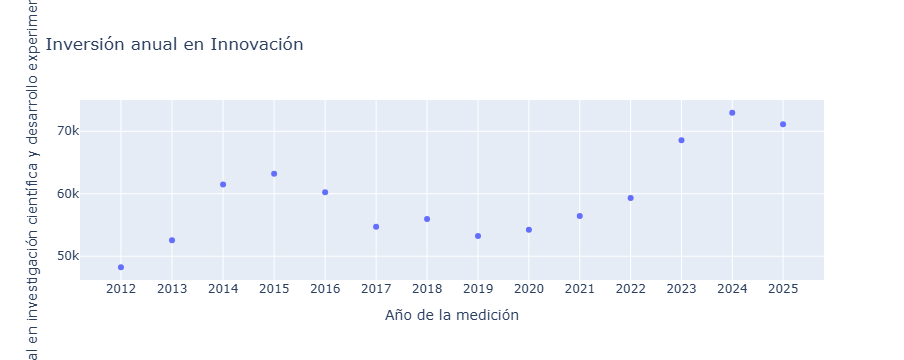

In [9]:
fig = px.scatter(
inversion_inv, 
    x="Periodo",
    y="Inversion_en_Innovacion",
    log_x=True,
    size_max=60,
    title="Inversión anual en Innovación",
    labels={"Periodo":"Año de la medición",
            "Inversion_en_Innovacion":" Gasto Federal en investigación científica y desarrollo experimental anual"}
)

fig.show()

In [23]:
innovacion_ran.head()

,Economies,Year,Score,Rank,Abreviatura
24,Angola,2011,0.0,0,AO
120,Barbados,2011,0.0,0,BB
132,Bielorrusia,2011,0.0,0,BY
156,Belice,2011,0.0,0,BZ
180,Bután,2011,0.0,0,BT


In [12]:
innovacion_ran = innovacion_ran.sort_values(by=["Year", "Score"], ascending=[True, True])

In [14]:
innovacion_ran.head()

,Economies,Year,Score,Rank,Abreviatura
24,Angola,2011,0.0,0,AO
120,Barbados,2011,0.0,0,BB
132,Bielorrusia,2011,0.0,0,BY
156,Belice,2011,0.0,0,BZ
180,Bután,2011,0.0,0,BT


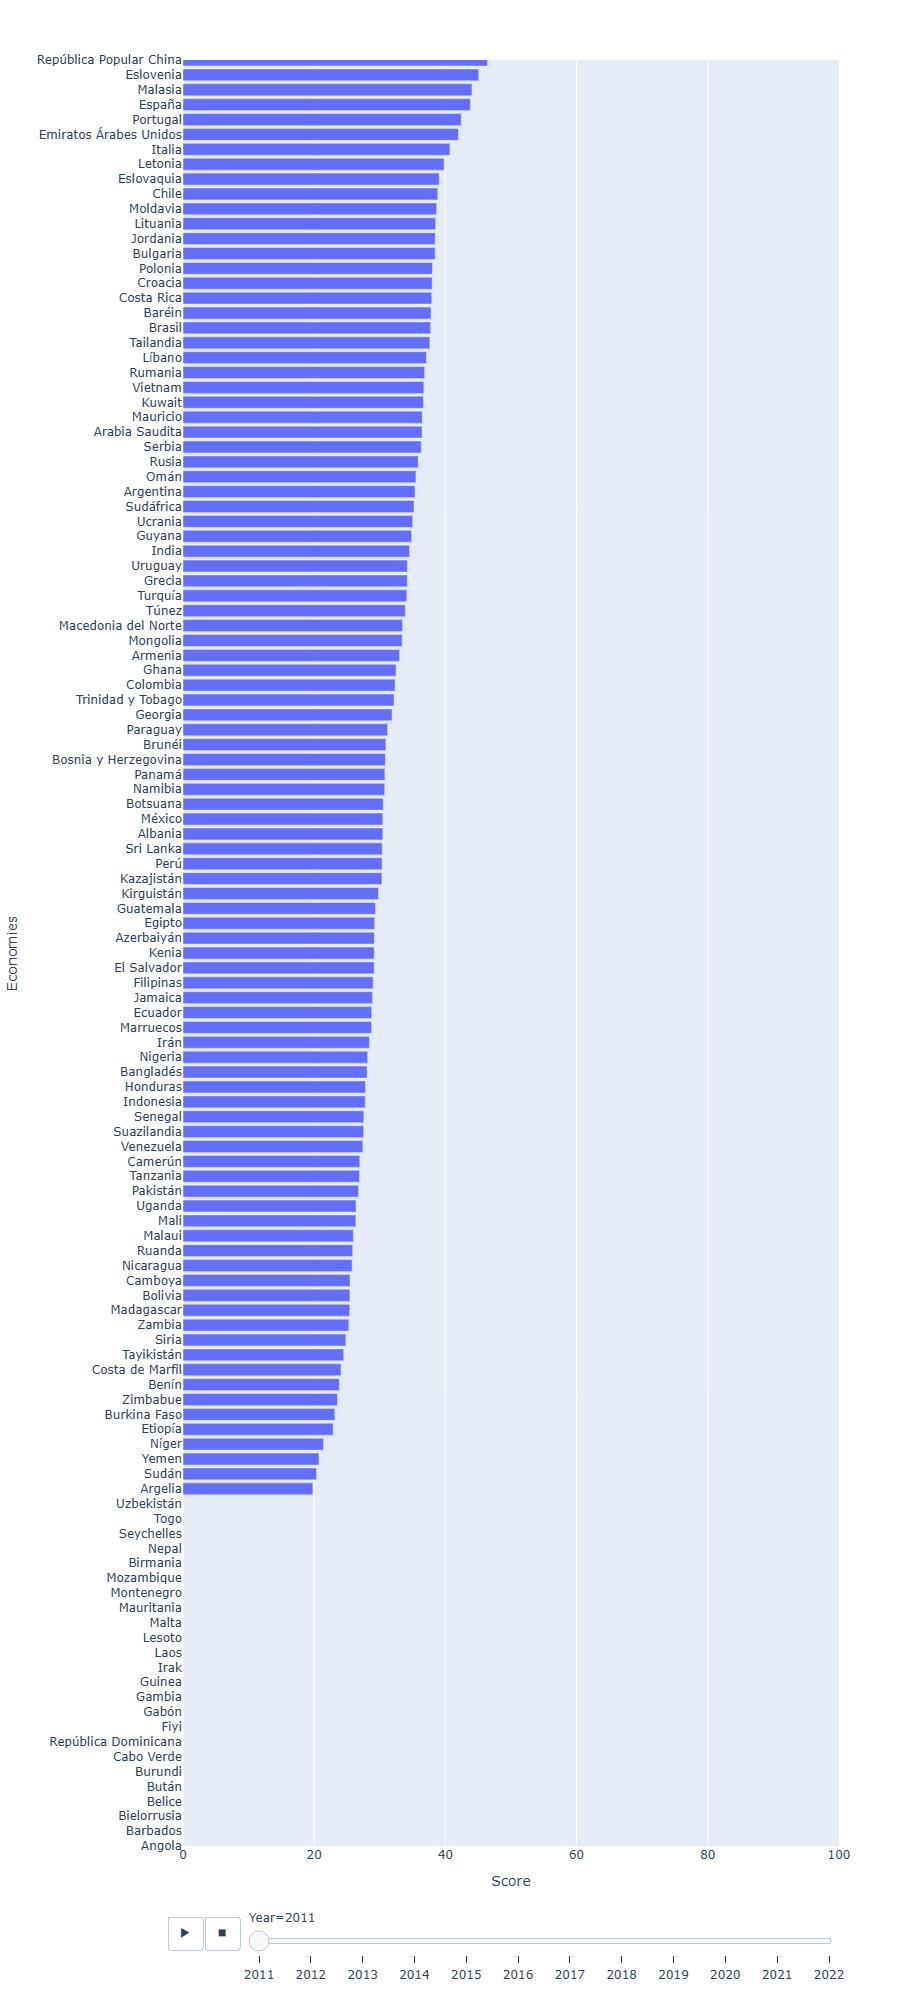

In [22]:
#mascara = innovacion_ran['Economies']=='Mexico'
#innovacion_ran = innovacion_ran[mascara]



fig = px.bar(
    innovacion_ran, 
    x="Score",            
    y="Economies",   
    animation_frame="Year", 
    animation_group="Economies",
    orientation='h',
    color_discrete_map={'México': '#006847', 'Otros': 'lightslategray'},
    range_x=[0,100],
    range_y=[0, 120],
    height=2000

)



fig.show()

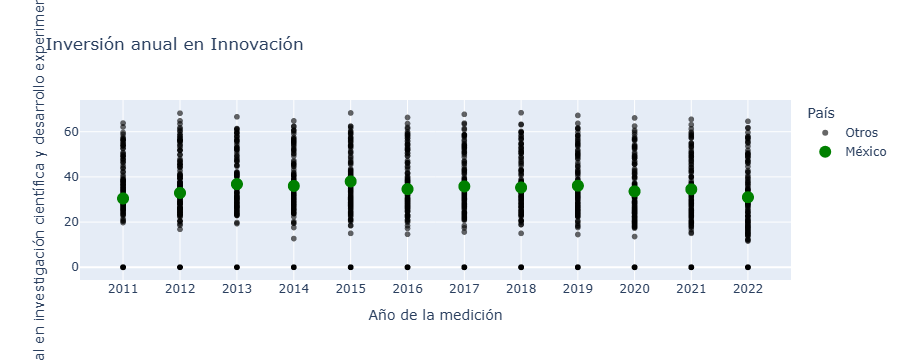

In [29]:
import plotly.express as px

# 1. Creamos la columna para diferenciar a México de los demás
innovacion_ran['Color_Pais'] = innovacion_ran['Economies'].apply(
    lambda x: 'México' if x == 'México' else 'Otros'
)

# 2. Generamos el gráfico con los nombres de tus columnas
fig = px.scatter(
    innovacion_ran, 
    x="Year", # Antes 'Periodo'
    y="Score", # Antes 'Inversion_en_Innovacion'
    color="Color_Pais",
    color_discrete_map={
        "México": "green",
        "Otros": "black"
    },
    log_x=True,
    size_max=60,
    title="Inversión anual en Innovación",
    labels={
        "Year": "Año de la medición",
        "Score": "Gasto Federal en investigación científica y desarrollo experimental anual",
        "Color_Pais": "País"
    }
)

# Mejoramos la estética: forzamos a que los puntos negros se vean un poco más tenues 
# para que México resalte aún más
fig.update_traces(marker=dict(opacity=0.6), selector=dict(name='Otros'))
fig.update_traces(marker=dict(opacity=1.0, size=12), selector=dict(name='México'))

fig.show()

In [28]:
print(inversion_inv.columns.tolist())

['Periodo', 'Producto_Interno_Bruto_Anual', 'Inversion_en_Innovacion', 'Porcentaje']


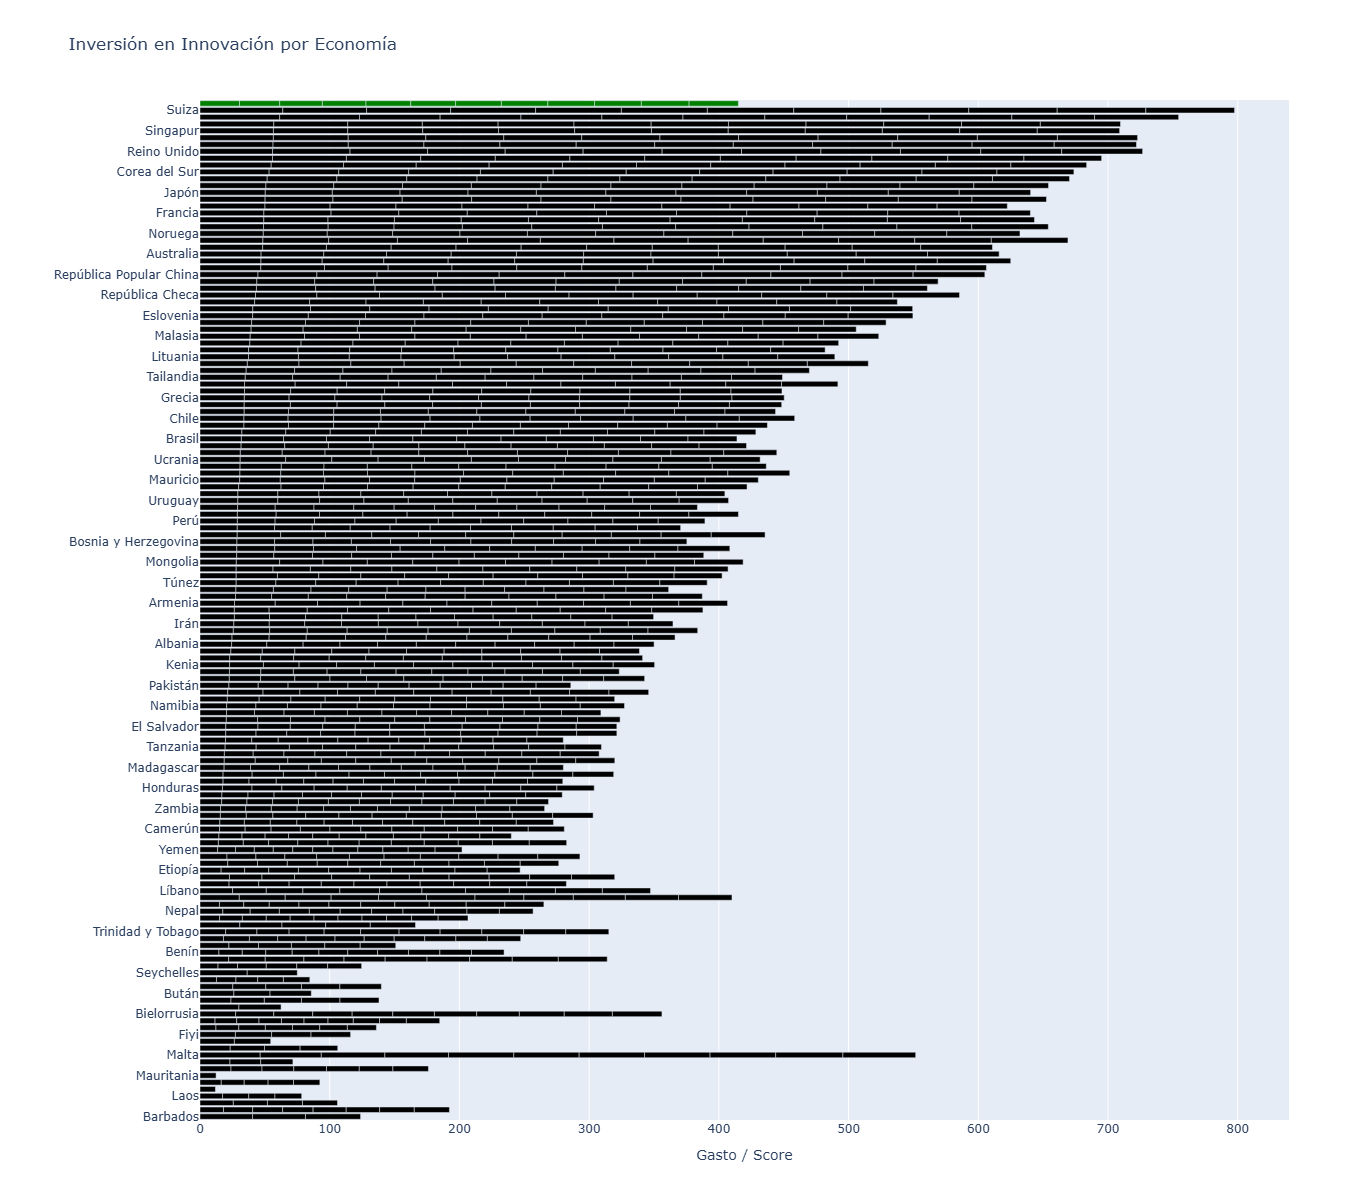

In [31]:
import plotly.express as px

# 1. Ordenamos los datos por Score para que se vea como una "escalera" (igual que tus fotos)
# Si quieres que el más alto esté arriba, usa ascending=True
innovacion_ran = innovacion_ran.sort_values("Score", ascending=True)

# 2. Creamos la columna lógica para el color
innovacion_ran['Color_Logic'] = innovacion_ran['Economies'].apply(
    lambda x: 'México' if str(x).strip() == 'México' else 'Otros'
)

# 3. Creamos el gráfico de barras
fig = px.bar(
    innovacion_ran, 
    x="Score", 
    y="Economies",  # Esto mantiene los nombres individuales en el eje Y
    orientation='h', # Barras horizontales
    color="Color_Logic", # El color se define por la categoría (México vs Otros)
    color_discrete_map={
        "México": "green",
        "Otros": "black"
    },
    title="Inversión en Innovación por Economía",
    labels={"Score": "Puntaje", "Economies": "País"},
    height=1200 # Aumentamos la altura para que se lean bien todos los nombres
)

# 4. Ajustes estéticos finales
fig.update_layout(
    showlegend=False, # Ocultamos la leyenda para que se vea más limpio
    margin=dict(l=200), # Margen izquierdo amplio para que quepan los nombres de países
    xaxis_title="Gasto / Score",
    yaxis_title=None
)

fig.show()